# TQQQ EMA5 / EMA30 金叉死叉回测

策略规则：

- 标的：`TQQQ`
- 数据：Yahoo Finance 日线复权价格，起始日期 `2015-01-01`，结束到今天
- 买入：EMA5 上穿 EMA30
- 卖出：EMA5 下穿 EMA30
- 执行假设：当天收盘后产生信号，下一交易日持仓生效，避免偷看未来
- 仓位：满仓或空仓，不加杠杆，不计滑点
- 手续费：每次买入/卖出固定扣除 `$0.99`


In [28]:
# 如果 notebook 环境缺依赖，先运行下面这行：
# %pip install -q yfinance pandas matplotlib

from datetime import date

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [46]:
SYMBOL = "TQQQ"
START_DATE = "2015-01-01"
END_DATE = date.today().isoformat()
INITIAL_CAPITAL = 10_000
COMMISSION_PER_TRADE = 0.99

# EMA 参数。short_window 上穿 long_window 买入；下穿卖出。
SHORT_WINDOW = 5
LONG_WINDOW = 30

raw = yf.download(
    SYMBOL,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise RuntimeError("没有下载到行情数据，请检查网络、yfinance 或标的代码。")

df = raw.copy()
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.rename(columns=str.lower)
df = df[["open", "high", "low", "close", "volume"]].dropna()
df.tail()


Price,open,high,low,close,volume
Date,,,,,
2026-04-07,43.4500,44.2100,41.8400,44.1500,131796200
2026-04-08,48.6400,48.9200,47.1500,48.0000,102015100
2026-04-09,48.0200,49.0900,47.3100,48.9600,78953600
2026-04-10,49.3600,49.8100,48.8200,49.1700,65481600
2026-04-13,48.7800,50.7400,48.4600,50.6600,66043900


## 生成 MA 信号

`signal` 是收盘后看到的趋势信号；`position` 是下一交易日实际持仓。这样不会把当天收盘信号用于当天收益。

In [47]:
bt = df.copy()
bt["ema_short"] = bt["close"].ewm(span=SHORT_WINDOW, adjust=False).mean()
bt["ema_long"] = bt["close"].ewm(span=LONG_WINDOW, adjust=False).mean()

# 短均线在长均线上方时持有；否则空仓。
bt["signal"] = (bt["ema_short"] > bt["ema_long"]).astype(int)

# 保持原来的 close-to-close 回测口径：
# 第 t 日收盘看到 EMA 信号后，持仓影响第 t+1 日 close 相对第 t 日 close 的收益。
bt["position"] = bt["signal"].shift(1).fillna(0).astype(int)
bt["trade_signal"] = bt["position"].diff().fillna(bt["position"]).astype(int)

bt["daily_return"] = bt["close"].pct_change().fillna(0)
bt["strategy_return_before_fee"] = bt["position"] * bt["daily_return"]

# 在原来的收益曲线上扣固定手续费。这样不会因为加入手续费而改变进出场时点。
equity_values = []
commission_values = []
equity = INITIAL_CAPITAL

for row in bt.itertuples():
    equity *= 1 + float(row.strategy_return_before_fee)
    commission = COMMISSION_PER_TRADE if int(row.trade_signal) != 0 else 0.0
    equity -= commission
    equity_values.append(equity)
    commission_values.append(commission)

bt["commission"] = commission_values
bt["strategy_equity"] = equity_values
bt["buy_hold_equity"] = INITIAL_CAPITAL * (bt["close"] / bt["close"].iloc[0])
bt["strategy_return"] = bt["strategy_equity"].pct_change().fillna(0)

bt[["close", "ema_short", "ema_long", "signal", "position", "trade_signal", "commission", "strategy_equity", "buy_hold_equity"]].tail()


Price,close,ema_short,ema_long,signal,position,trade_signal,commission,strategy_equity,buy_hold_equity
Date,,,,,,,,,
2026-04-07,44.1500,43.2896,45.4628,0,0,0,0.0000,"163,957.0464","230,064.0608"
2026-04-08,48.0000,44.8597,45.6265,0,0,0,0.0000,"163,957.0464","250,126.2635"
2026-04-09,48.9600,46.2265,45.8416,1,0,0,0.0000,"163,957.0464","255,128.7840"
2026-04-10,49.1700,47.2077,46.0563,1,1,1,0.9900,"164,659.3005","256,223.0817"
2026-04-13,50.6600,48.3584,46.3533,1,1,0,0.0000,"169,648.9821","263,987.4265"


## 统计结果

In [48]:
def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    drawdown = equity / peak - 1
    return drawdown.min()


def annualized_return(equity: pd.Series) -> float:
    days = (equity.index[-1] - equity.index[0]).days
    years = days / 365.25
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1


def annualized_volatility(returns: pd.Series) -> float:
    return returns.std() * (252 ** 0.5)


strategy_total_return = bt["strategy_equity"].iloc[-1] / INITIAL_CAPITAL - 1
buy_hold_total_return = bt["buy_hold_equity"].iloc[-1] / INITIAL_CAPITAL - 1
total_commission = bt["commission"].sum()

# closed_trades 会在后面的交易统计单元格生成；这里先只统计资金曲线指标。
summary = pd.DataFrame(
    {
        "最终资产": [bt["strategy_equity"].iloc[-1], bt["buy_hold_equity"].iloc[-1]],
        "总收益率": [strategy_total_return, buy_hold_total_return],
        "年化收益率": [annualized_return(bt["strategy_equity"]), annualized_return(bt["buy_hold_equity"])],
        "最大回撤": [max_drawdown(bt["strategy_equity"]), max_drawdown(bt["buy_hold_equity"])],
        "年化波动率": [annualized_volatility(bt["strategy_return"]), annualized_volatility(bt["daily_return"])],
        "手续费合计": [total_commission, 0.0],
    },
    index=["EMA5/EMA30 策略", "买入持有 TQQQ"],
)

summary_display = summary.copy()
summary_display["最终资产"] = summary_display["最终资产"].map(lambda x: f"${x:,.2f}")
summary_display["手续费合计"] = summary_display["手续费合计"].map(lambda x: f"${x:,.2f}")
for col in ["总收益率", "年化收益率", "最大回撤", "年化波动率"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

summary_display


,最终资产,总收益率,年化收益率,最大回撤,年化波动率,手续费合计
EMA5/EMA30 策略,"$169,648.98",1596.49%,28.54%,-49.58%,38.66%,$119.79
买入持有 TQQQ,"$263,987.43",2539.87%,33.68%,-81.66%,64.82%,$0.00


## 交易记录

`trade_date` 是实际仓位变化日，也就是信号产生后的下一交易日。

In [49]:
trades = bt.loc[bt["trade_signal"] != 0, ["close", "ema_short", "ema_long", "trade_signal", "commission", "strategy_equity"]].copy()
trades["action"] = trades["trade_signal"].map({1: "BUY", -1: "SELL"})
trades = trades.rename_axis("trade_date").reset_index()
trades = trades[["trade_date", "action", "close", "ema_short", "ema_long", "commission", "strategy_equity"]]
trades.tail(20)


Price,trade_date,action,close,ema_short,ema_long,commission,strategy_equity
101,2024-09-04,SELL,30.4058,31.8131,32.7942,0.9900,"115,284.5538"
102,2024-09-17,BUY,32.7027,32.3242,32.1679,0.9900,"115,352.9687"
103,2024-11-05,SELL,35.9907,35.5960,35.6066,0.9900,"122,302.4850"
104,2024-11-07,BUY,40.7325,38.0450,36.1368,0.9900,"128,024.2255"
105,2025-01-02,SELL,38.9272,40.2548,40.9659,0.9900,"123,127.0768"
106,2025-01-22,BUY,43.4670,41.4625,40.5902,0.9900,"127,904.3337"
107,2025-02-04,SELL,41.4124,40.9236,40.8288,0.9900,"117,589.4164"
108,2025-02-05,BUY,41.9520,41.2664,40.9013,0.9900,"119,120.6497"
109,2025-02-26,SELL,38.6747,40.1591,41.5296,0.9900,"109,110.9696"
110,2025-05-02,BUY,29.5087,27.8586,27.0646,0.9900,"114,222.4572"


In [50]:
# 展示所有交易信号，不截断。
# trade_date 是策略持仓发生变化的日期；该行 close 是回测记录里的参考价格。
all_trades = trades.copy()
all_trades["trade_date"] = pd.to_datetime(all_trades["trade_date"]).dt.date
all_trades = all_trades.rename(
    columns={
        "trade_date": "交易日期",
        "action": "动作",
        "close": "参考收盘价",
        "ema_short": f"EMA{SHORT_WINDOW}",
        "ema_long": f"EMA{LONG_WINDOW}",
        "commission": "手续费",
        "strategy_equity": "交易后资产",
    }
)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(all_trades)


Price,交易日期,动作,参考收盘价,EMA5,EMA30,手续费,交易后资产
0,2015-01-26,BUY,1.9752,1.9315,1.8876,0.9900,"9,976.9427"
1,2015-01-29,SELL,1.8428,1.8545,1.8752,0.9900,"9,045.2534"
2,2015-02-06,BUY,1.9081,1.8994,1.8789,0.9900,"8,879.7675"
3,2015-03-13,SELL,2.0223,2.0613,2.0820,0.9900,"9,532.9808"
4,2015-03-18,BUY,2.1722,2.1151,2.0906,0.9900,"9,806.3090"
5,2015-03-27,SELL,2.0372,2.0758,2.1009,0.9900,"9,107.9517"
6,2015-04-10,BUY,2.1664,2.1164,2.0933,0.9900,"9,215.9472"
7,2015-05-07,SELL,2.1293,2.1547,2.1656,0.9900,"8,904.0970"
8,2015-05-11,BUY,2.1831,2.1759,2.1693,0.9900,"8,805.3854"
9,2015-05-14,SELL,2.2620,2.1993,2.1742,0.9900,"8,735.5146"


In [51]:
completed = []
entry = None

for row in trades.itertuples(index=False):
    if row.action == "BUY":
        entry = row
    elif row.action == "SELL" and entry is not None:
        gross_return = row.close / entry.close - 1
        # 净收益按策略权益变化计算，已包含完整持有期间收益和买卖两边固定手续费。
        net_return = row.strategy_equity / entry.strategy_equity - 1
        completed.append(
            {
                "entry_date": entry.trade_date,
                "entry_price": entry.close,
                "entry_equity_after_fee": entry.strategy_equity,
                "exit_date": row.trade_date,
                "exit_price": row.close,
                "exit_equity_after_fee": row.strategy_equity,
                "gross_return": gross_return,
                "net_return_after_fee": net_return,
                "commission": float(entry.commission) + float(row.commission),
            }
        )
        entry = None

closed_trades = pd.DataFrame(completed)
win_rate = None
if not closed_trades.empty:
    win_rate = (closed_trades["net_return_after_fee"] > 0).mean()
    trade_stats = pd.DataFrame(
        {
            "完整交易回合数": [len(closed_trades)],
            "盈利回合数": [int((closed_trades["net_return_after_fee"] > 0).sum())],
            "胜率": [f"{win_rate:.2%}"],
            "手续费合计": [f"${bt['commission'].sum():,.2f}"],
            "平均单笔净收益": [f"{closed_trades['net_return_after_fee'].mean():.2%}"],
        }
    )
    display(trade_stats)

    closed_trades_display = closed_trades.tail(20).copy()
    for col in ["entry_price", "exit_price", "entry_equity_after_fee", "exit_equity_after_fee", "commission"]:
        closed_trades_display[col] = closed_trades_display[col].map(lambda x: f"${x:,.2f}")
    closed_trades_display["gross_return"] = closed_trades_display["gross_return"].map(lambda x: f"{x:.2%}")
    closed_trades_display["net_return_after_fee"] = closed_trades_display["net_return_after_fee"].map(lambda x: f"{x:.2%}")
    display(closed_trades_display)
else:
    print("还没有完整买卖闭环。")

if entry is not None:
    latest_price = bt["close"].iloc[-1]
    latest_equity = bt["strategy_equity"].iloc[-1]
    print(f"当前仍持仓：入场日 {entry.trade_date.date()}，入场参考价 ${entry.close:,.2f}，最新价 ${latest_price:,.2f}，当前策略资产 ${latest_equity:,.2f}")


,完整交易回合数,盈利回合数,胜率,手续费合计,平均单笔净收益
0,60,21,35.00%,$119.79,5.91%


,entry_date,entry_price,entry_equity_after_fee,exit_date,exit_price,exit_equity_after_fee,gross_return,net_return_after_fee,commission
40,2022-11-15,$10.96,"$62,983.21",2022-12-08,$10.17,"$56,426.04",-7.23%,-10.41%,$1.98
41,2022-12-14,$10.41,"$55,085.78",2022-12-16,$9.10,"$49,626.74",-12.57%,-9.91%,$1.98
42,2023-01-17,$9.70,"$49,897.35",2023-02-27,$10.68,"$53,747.90",10.04%,7.72%,$1.98
43,2023-03-07,$10.89,"$51,739.35",2023-03-10,$10.02,"$49,685.22",-7.94%,-3.97%,$1.98
44,2023-03-17,$11.79,"$48,947.11",2023-08-10,$19.32,"$79,820.09",63.82%,63.07%,$1.98
45,2023-08-31,$20.56,"$80,540.25",2023-09-19,$19.18,"$75,605.13",-6.69%,-6.13%,$1.98
46,2023-10-12,$18.90,"$74,720.09",2023-10-19,$17.35,"$70,491.13",-8.18%,-5.66%,$1.98
47,2023-11-07,$19.00,"$72,474.52",2024-04-11,$30.23,"$110,161.51",59.15%,52.00%,$1.98
48,2024-04-12,$28.77,"$104,839.92",2024-04-15,$27.33,"$104,838.93",-5.02%,-0.00%,$1.98
49,2024-05-08,$28.64,"$104,641.00",2024-07-24,$32.19,"$131,835.15",12.40%,25.99%,$1.98


当前仍持仓：入场日 2026-04-10，入场参考价 $49.17，最新价 $50.66，当前策略资产 $169,648.98


## 类似视频里的交易收益表

`total_fund` 是每个完整卖出回合后的账户总资产；`return_percentage` 是这一完整买卖回合扣除手续费后的收益率百分比。


In [52]:
if closed_trades.empty:
    print("还没有完整买卖闭环。")
else:
    video_like_table = closed_trades.copy()
    video_like_table["trade_no"] = range(len(video_like_table))
    video_like_table["total_fund"] = video_like_table["exit_equity_after_fee"]
    video_like_table["return_percentage"] = video_like_table["net_return_after_fee"] * 100
    video_like_table = video_like_table[
        [
            "trade_no",
            "entry_date",
            "entry_price",
            "exit_date",
            "exit_price",
            "total_fund",
            "return_percentage",
            "commission",
        ]
    ]

    video_like_display = video_like_table.copy()
    video_like_display["entry_date"] = pd.to_datetime(video_like_display["entry_date"]).dt.date
    video_like_display["exit_date"] = pd.to_datetime(video_like_display["exit_date"]).dt.date
    for col in ["entry_price", "exit_price", "total_fund", "commission"]:
        video_like_display[col] = video_like_display[col].map(lambda x: round(float(x), 2))
    video_like_display["return_percentage"] = video_like_display["return_percentage"].map(lambda x: round(float(x), 2))

    print(f"Lose: {(video_like_table['return_percentage'] <= 0).sum()}  Win: {(video_like_table['return_percentage'] > 0).sum()}")
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 240):
        display(video_like_display)


Lose: 39  Win: 21


,trade_no,entry_date,entry_price,exit_date,exit_price,total_fund,return_percentage,commission
0,0,2015-01-26,1.9800,2015-01-29,1.8400,"9,045.2500",-9.3400,1.9800
1,1,2015-02-06,1.9100,2015-03-13,2.0200,"9,532.9800",7.3600,1.9800
2,2,2015-03-18,2.1700,2015-03-27,2.0400,"9,107.9500",-7.1200,1.9800
3,3,2015-04-10,2.1700,2015-05-07,2.1300,"8,904.1000",-3.3800,1.9800
4,4,2015-05-11,2.1800,2015-05-14,2.2600,"8,735.5100",-0.7900,1.9800
5,5,2015-05-15,2.2600,2015-06-09,2.1600,"8,380.0400",-4.0500,1.9800
6,6,2015-06-19,2.2800,2015-06-30,2.1100,"7,556.6700",-8.4200,1.9800
7,7,2015-07-16,2.3900,2015-08-12,2.2900,"7,462.2000",-4.9500,1.9800
8,8,2015-10-09,1.9800,2015-12-14,2.2500,"8,368.4700",10.8100,1.9800
9,9,2015-12-30,2.3600,2016-01-05,2.1100,"7,370.5400",-9.6100,1.9800


## 净值曲线与 MA 图

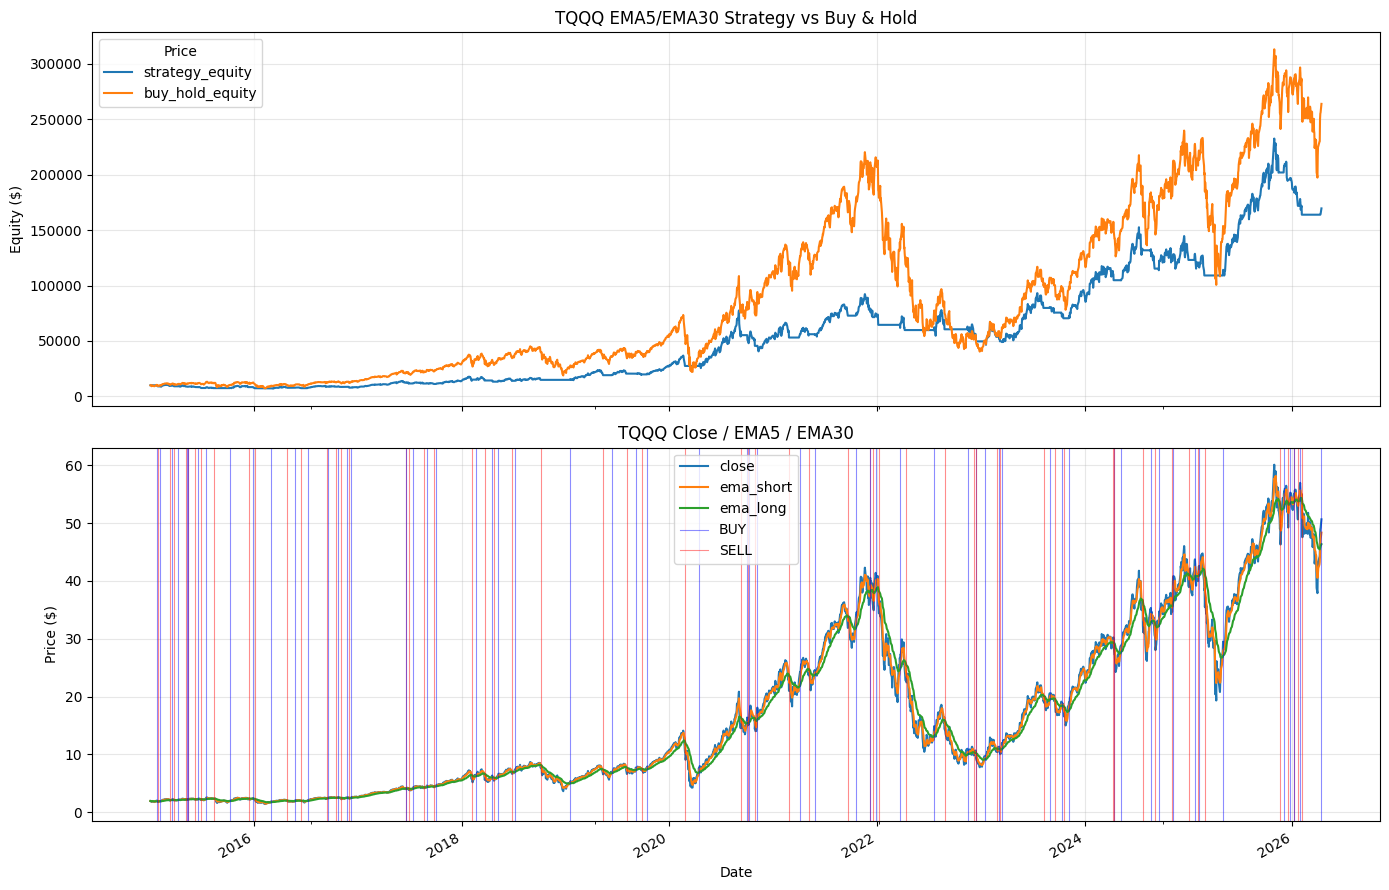

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

bt[["strategy_equity", "buy_hold_equity"]].plot(ax=axes[0])
axes[0].set_title(f"{SYMBOL} EMA5/EMA30 Strategy vs Buy & Hold")
axes[0].set_ylabel("Equity ($)")
axes[0].grid(True, alpha=0.3)

bt[["close", "ema_short", "ema_long"]].plot(ax=axes[1])

# 用细竖线标记每次实际交易日：蓝色是买入，红色是卖出。
# trade_date 来自 position 变化日，也就是信号生成后的下一交易日。
buy_label_added = False
sell_label_added = False
for row in trades.itertuples(index=False):
    if row.action == "BUY":
        axes[1].axvline(
            row.trade_date,
            color="blue",
            linewidth=0.8,
            alpha=0.45,
            label="BUY" if not buy_label_added else None,
        )
        buy_label_added = True
    elif row.action == "SELL":
        axes[1].axvline(
            row.trade_date,
            color="red",
            linewidth=0.8,
            alpha=0.45,
            label="SELL" if not sell_label_added else None,
        )
        sell_label_added = True

axes[1].set_title(f"{SYMBOL} Close / EMA5 / EMA30")
axes[1].set_ylabel("Price ($)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
